In [6]:
# Install Prophet and XGBoost
import sys

!{sys.executable} -m pip install prophet
!{sys.executable} -m pip install xgboost
!{sys.executable} -m pip install statsmodels


In [7]:
# TASK 3: Energy Consumption Time Series Forecasting
# Goal: Forecast household energy usage using 3 models
# Models: ARIMA, Prophet, XGBoost

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time Series — ARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Prophet (Facebook)
from prophet import Prophet

# XGBoost
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")


All libraries imported!


In [8]:
#Generate Dataset

#  CREATE REALISTIC ENERGY DATASET
# We simulate 2 years of hourly electricity consumption
# Real patterns included:
#   - Higher usage in morning & evening
#   - Higher usage on weekdays
#   - Seasonal variation (summer = more AC usage)

np.random.seed(42)

# Create hourly timestamps for 2 years
dates = pd.date_range(
    start='2022-01-01',
    end='2023-12-31 23:00:00',
    freq='h'                    # 'h' = hourly frequency
)

n = len(dates)
print(f"Total hours: {n}")      # Should be ~17,520

# Base consumption
consumption = np.zeros(n)

for i, dt in enumerate(dates):
    # Base load (always on appliances)
    base = 0.5

    # Hour of day pattern
    # Morning peak (7-9 AM) and Evening peak (6-10 PM)
    hour = dt.hour
    if 7 <= hour <= 9:
        hour_factor = 2.0       # Morning rush
    elif 18 <= hour <= 22:
        hour_factor = 2.5       # Evening peak
    elif 0 <= hour <= 5:
        hour_factor = 0.3       # Night — low usage
    else:
        hour_factor = 1.0       # Normal daytime

    # Weekday vs Weekend
    # Weekdays: people away → less usage during day
    # Weekends: people home → more usage
    if dt.weekday() < 5:        # Monday=0, Friday=4
        day_factor = 1.0
    else:
        day_factor = 1.3        # Weekend boost

    # Seasonal factor (Summer = more cooling needed)
    month = dt.month
    if month in [6, 7, 8]:     # Summer
        season_factor = 1.8
    elif month in [12, 1, 2]:  # Winter
        season_factor = 1.4
    else:
        season_factor = 1.0     # Spring/Autumn

    # Random noise (real data is never perfect)
    noise = np.random.normal(0, 0.1)

    # Final consumption value (kWh)
    consumption[i] = base * hour_factor * day_factor * season_factor + noise
    consumption[i] = max(0.1, consumption[i])  # No negative values

# Create DataFrame
df = pd.DataFrame({
    'ds': dates,                # 'ds' = datestamp (Prophet needs this name)
    'y' : consumption           # 'y'  = value (Prophet needs this name)
})

df.set_index('ds', inplace=True)

print("Dataset created!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic Stats:")
print(df['y'].describe().round(3))

Total hours: 17520
Dataset created!
Shape: (17520, 1)

First 5 rows:
                            y
ds                           
2022-01-01 00:00:00  0.322671
2022-01-01 01:00:00  0.259174
2022-01-01 02:00:00  0.337769
2022-01-01 03:00:00  0.425303
2022-01-01 04:00:00  0.249585

Basic Stats:
count    17520.000
mean         0.895
std          0.649
min          0.100
25%          0.384
50%          0.743
75%          1.251
max          3.249
Name: y, dtype: float64


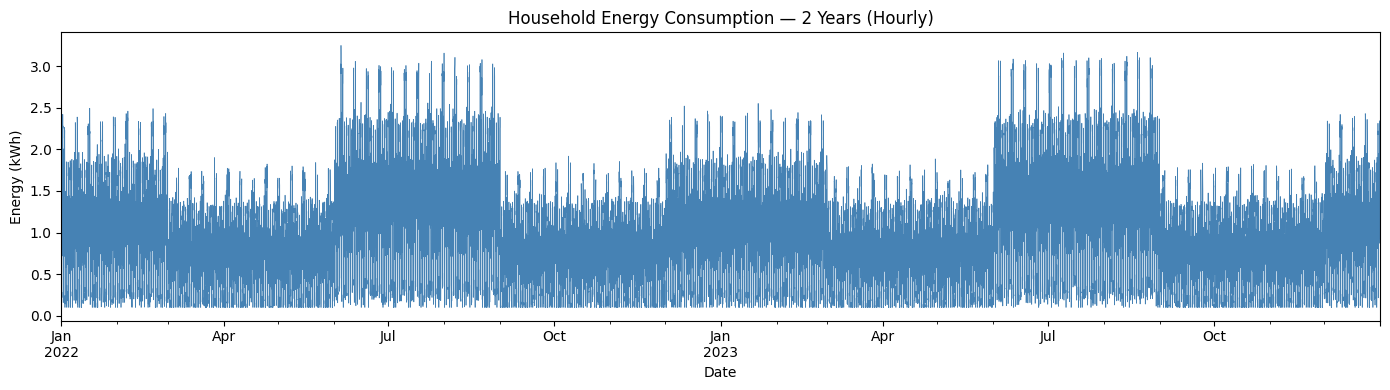

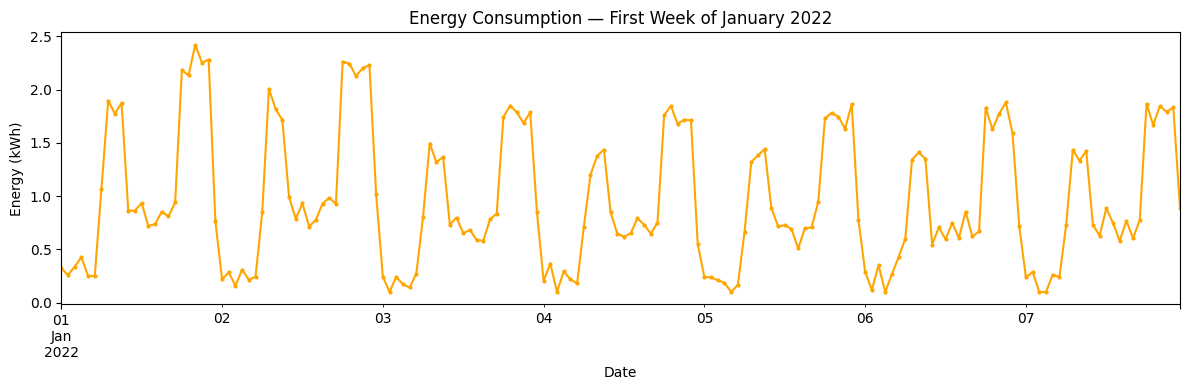

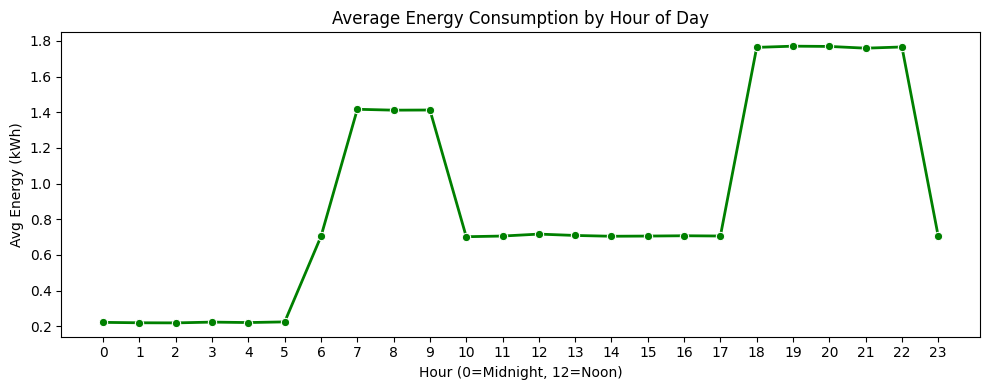

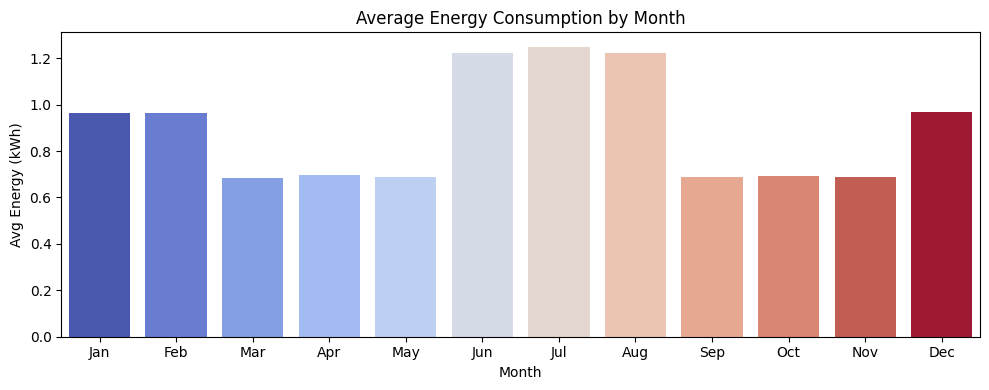

In [9]:
#  EXPLORATORY DATA ANALYSIS

# --- Plot 1: Full time series overview ---
plt.figure(figsize=(14, 4))
df['y'].plot(color='steelblue', linewidth=0.5)
plt.title('Household Energy Consumption — 2 Years (Hourly)')
plt.xlabel('Date')
plt.ylabel('Energy (kWh)')
plt.tight_layout()
plt.show()

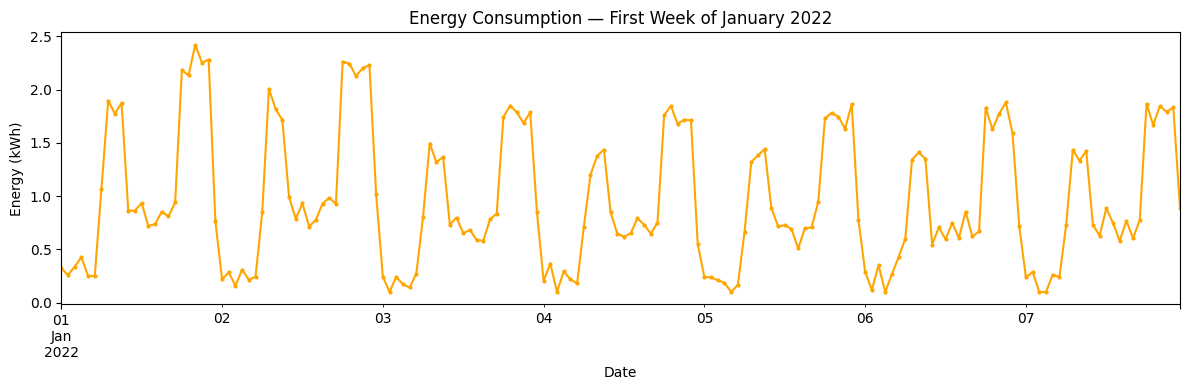

In [10]:
# --- Plot 2: One week zoomed in ---
one_week = df['2022-01-01':'2022-01-07']
plt.figure(figsize=(12, 4))
one_week['y'].plot(color='orange', linewidth=1.5, marker='o', markersize=2)
plt.title('Energy Consumption — First Week of January 2022')
plt.xlabel('Date')
plt.ylabel('Energy (kWh)')
plt.tight_layout()
plt.show()

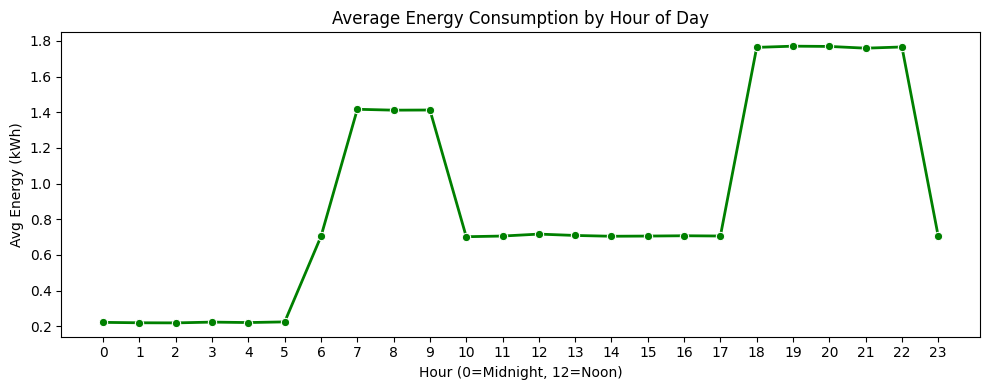

In [12]:
# --- Plot 3: Average consumption by Hour ---
df['hour'] = df.index.hour
hourly_avg = df.groupby('hour')['y'].mean()

plt.figure(figsize=(10, 4))
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values,
             color='green', linewidth=2, marker='o')
plt.title('Average Energy Consumption by Hour of Day')
plt.xlabel('Hour (0=Midnight, 12=Noon)')
plt.ylabel('Avg Energy (kWh)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

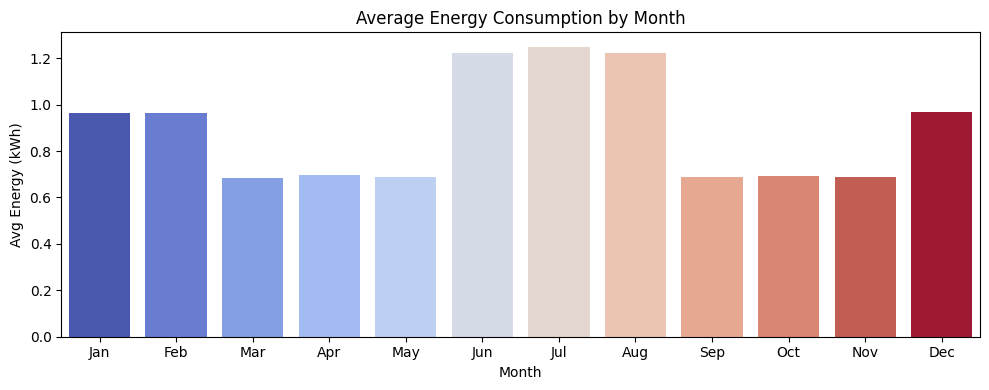

In [13]:
# --- Plot 4: Average consumption by Month ---
df['month'] = df.index.month
monthly_avg = df.groupby('month')['y'].mean()

plt.figure(figsize=(10, 4))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values,
            hue=monthly_avg.index,
            palette='coolwarm', legend=False)
plt.title('Average Energy Consumption by Month')
plt.xlabel('Month')
plt.ylabel('Avg Energy (kWh)')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()
# INSIGHT: Summer months (Jun-Aug) consume most energy

# Clean up temp columns
df.drop(['hour', 'month'], axis=1, inplace=True)

In [14]:
# RESAMPLE TO DAILY DATA 
# Hourly data = 17,520 rows — too much for ARIMA
# We resample to daily averages = 730 rows (manageable)

df_daily = df['y'].resample('D').mean()   # Daily average kWh
df_daily = df_daily.reset_index()
df_daily.columns = ['ds', 'y']

print("Daily data shape:", df_daily.shape)
print(df_daily.head())

# ── STEP 4: FEATURE ENGINEERING ──────────────────────────
# Extract time-based features for XGBoost
# XGBoost needs numeric features — not timestamps

df_feat = df_daily.copy()

# Extract useful time features
df_feat['day_of_week']  = df_feat['ds'].dt.dayofweek  # 0=Mon, 6=Sun
df_feat['month']        = df_feat['ds'].dt.month       # 1-12
df_feat['day_of_year']  = df_feat['ds'].dt.dayofyear  # 1-365
df_feat['week_of_year'] = df_feat['ds'].dt.isocalendar().week.astype(int)
df_feat['is_weekend']   = (df_feat['day_of_week'] >= 5).astype(int)  # 1=weekend

# Lag features — yesterday's and last week's consumption
# These help XGBoost understand trends
df_feat['lag_1']  = df_feat['y'].shift(1)   # Yesterday
df_feat['lag_7']  = df_feat['y'].shift(7)   # Same day last week
df_feat['lag_30'] = df_feat['y'].shift(30)  # Same day last month

# Rolling averages — smooth out noise
df_feat['rolling_7']  = df_feat['y'].shift(1).rolling(7).mean()   # 7-day avg
df_feat['rolling_30'] = df_feat['y'].shift(1).rolling(30).mean()  # 30-day avg

# Drop rows with NaN (created by lag features)
df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

print("\nFeature engineered data shape:", df_feat.shape)
print("\nFeatures created:")
print(df_feat.columns.tolist())
print(df_feat.head())

Daily data shape: (730, 2)
          ds         y
0 2022-01-01  1.134111
1 2022-01-02  1.122579
2 2022-01-03  0.896195
3 2022-01-04  0.876824
4 2022-01-05  0.890114

Feature engineered data shape: (700, 12)

Features created:
['ds', 'y', 'day_of_week', 'month', 'day_of_year', 'week_of_year', 'is_weekend', 'lag_1', 'lag_7', 'lag_30', 'rolling_7', 'rolling_30']
          ds         y  day_of_week  month  day_of_year  week_of_year  \
0 2022-01-31  0.873376            0      1           31             5   
1 2022-02-01  0.890875            1      2           32             5   
2 2022-02-02  0.897216            2      2           33             5   
3 2022-02-03  0.883016            3      2           34             5   
4 2022-02-04  0.900342            4      2           35             5   

   is_weekend     lag_1     lag_7    lag_30  rolling_7  rolling_30  
0           0  1.141559  0.880655  1.134111   0.961103    0.972025  
1           0  0.873376  0.894544  1.122579   0.960063    0.9

In [15]:
# ─ TRAIN/TEST SPLIT 
# Use last 60 days as test set
# Train on everything before that

test_size  = 60    # Last 60 days for testing
train_size = len(df_daily) - test_size

# For ARIMA and Prophet — use daily series
train_daily = df_daily.iloc[:train_size]
test_daily  = df_daily.iloc[train_size:]

print(f"Training days: {len(train_daily)}")
print(f"Testing days:  {len(test_daily)}")
print(f"Train period:  {train_daily['ds'].min()} to {train_daily['ds'].max()}")
print(f"Test period:   {test_daily['ds'].min()} to {test_daily['ds'].max()}")

# For XGBoost — use feature engineered data
feature_cols = ['day_of_week', 'month', 'day_of_year',
                'week_of_year', 'is_weekend',
                'lag_1', 'lag_7', 'lag_30',
                'rolling_7', 'rolling_30']

# Align test split with feature dataframe
split_idx   = len(df_feat) - test_size

X_train_xgb = df_feat[feature_cols].iloc[:split_idx]
y_train_xgb = df_feat['y'].iloc[:split_idx]
X_test_xgb  = df_feat[feature_cols].iloc[split_idx:]
y_test_xgb  = df_feat['y'].iloc[split_idx:]

print(f"\nXGBoost Train: {X_train_xgb.shape}")
print(f"XGBoost Test:  {X_test_xgb.shape}")

Training days: 670
Testing days:  60
Train period:  2022-01-01 00:00:00 to 2023-11-01 00:00:00
Test period:   2023-11-02 00:00:00 to 2023-12-31 00:00:00

XGBoost Train: (640, 10)
XGBoost Test:  (60, 10)


In [16]:
# MODEL 1 — ARIMA 
# ARIMA = AutoRegressive Integrated Moving Average
# A classical statistical model for time series
# Parameters: (p, d, q)
#   p = how many past values to use
#   d = how many times to difference (make stationary)
#   q = moving average order

print("Training ARIMA model...")
print("This may take 1-2 minutes...")

# Train ARIMA on training data
arima_model = ARIMA(
    train_daily['y'],
    order=(5, 1, 2)    # (p=5, d=1, q=2) — common good starting values
)
arima_fit = arima_model.fit()

# Forecast next 60 days
arima_forecast = arima_fit.forecast(steps=test_size)
arima_forecast = np.array(arima_forecast)

# Evaluate ARIMA
mae_arima  = mean_absolute_error(test_daily['y'], arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test_daily['y'], arima_forecast))

print(f"\nARIMA Results:")
print(f"   MAE  : {mae_arima:.4f} kWh")
print(f"   RMSE : {rmse_arima:.4f} kWh")

Training ARIMA model...
This may take 1-2 minutes...

ARIMA Results:
   MAE  : 0.1655 kWh
   RMSE : 0.2248 kWh


Training Prophet model...


17:12:53 - cmdstanpy - INFO - Chain [1] start processing
17:12:54 - cmdstanpy - INFO - Chain [1] done processing



Prophet Results:
   MAE  : 0.0402 kWh
   RMSE : 0.0527 kWh


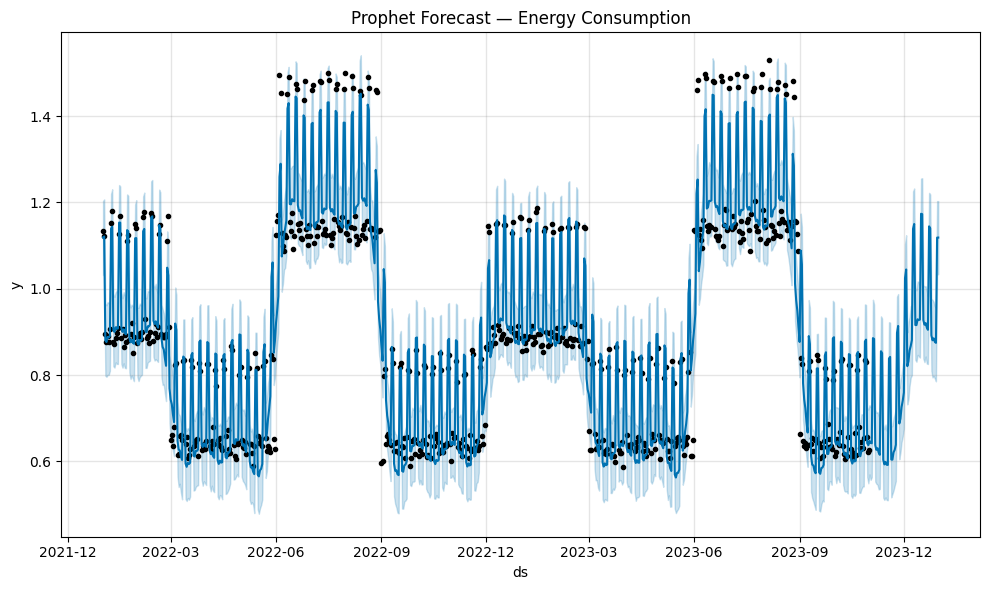

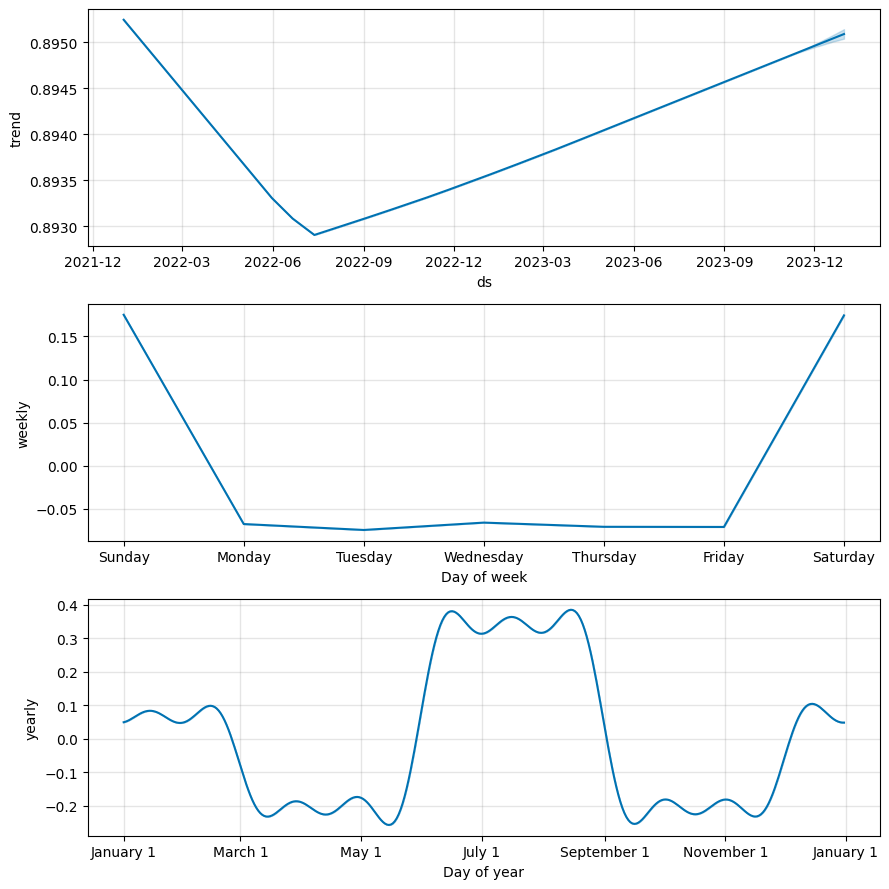

In [17]:
# MODEL 2 — PROPHET 
# Prophet = Facebook's forecasting library
# Great at handling:
#   - Seasonal patterns (daily, weekly, yearly)
#   - Holiday effects
#   - Missing data
# Input must have columns named 'ds' and 'y'

print("Training Prophet model...")

# Prophet needs columns named 'ds' and 'y' — already done!
prophet_model = Prophet(
    yearly_seasonality=True,    # Capture yearly patterns
    weekly_seasonality=True,    # Capture weekly patterns
    daily_seasonality=False,    # We're using daily data
    changepoint_prior_scale=0.05  # Flexibility of trend
)

# Fit on training data
prophet_model.fit(train_daily)

# Create future dataframe for prediction
future = prophet_model.make_future_dataframe(
    periods=test_size,          # Forecast 60 days ahead
    freq='D'
)

# Predict
prophet_pred = prophet_model.predict(future)

# Extract only test period predictions
prophet_forecast = prophet_pred['yhat'].iloc[-test_size:].values

# Evaluate Prophet
mae_prophet  = mean_absolute_error(test_daily['y'], prophet_forecast)
rmse_prophet = np.sqrt(mean_squared_error(test_daily['y'], prophet_forecast))

print(f"\nProphet Results:")
print(f"   MAE  : {mae_prophet:.4f} kWh")
print(f"   RMSE : {rmse_prophet:.4f} kWh")

# Prophet built-in plot
fig = prophet_model.plot(prophet_pred)
plt.title('Prophet Forecast — Energy Consumption')
plt.tight_layout()
plt.show()

# Prophet components (trend + seasonality)
fig2 = prophet_model.plot_components(prophet_pred)
plt.tight_layout()
plt.show()
# INSIGHT: See yearly trend and weekly seasonality separately

Training XGBoost model...

XGBoost Results:
   MAE  : 0.0347 kWh
   RMSE : 0.0640 kWh


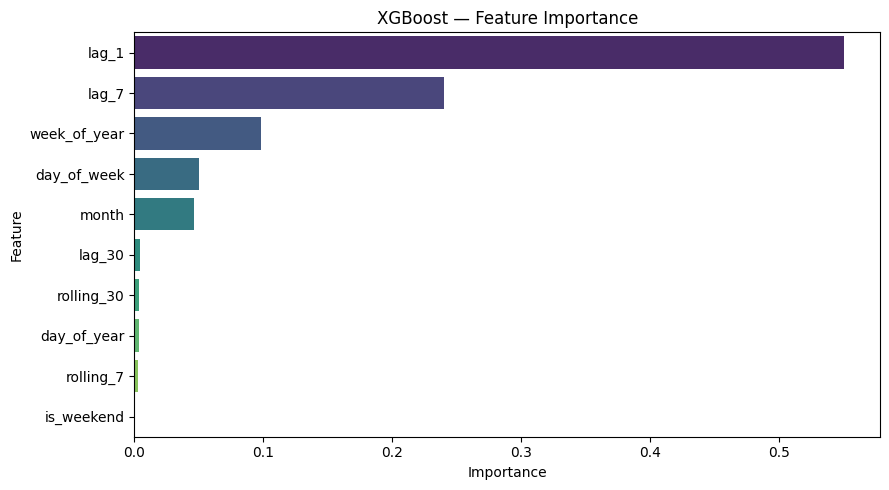

In [18]:
#  MODEL 3 — XGBOOST 
# XGBoost treats time series as a regression problem
# We feed it engineered features (lag, rolling avg, etc.)
# It learns patterns from those features

print("Training XGBoost model...")

xgb_model = XGBRegressor(
    n_estimators=500,       # Number of trees
    learning_rate=0.05,     # How fast model learns
    max_depth=5,            # Tree depth
    random_state=42,
    verbosity=0             # Silent training
)

xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_test_xgb, y_test_xgb)],  # Watch test performance
    verbose=False
)

# Predict
xgb_forecast = xgb_model.predict(X_test_xgb)

# Evaluate XGBoost
mae_xgb  = mean_absolute_error(y_test_xgb, xgb_forecast)
rmse_xgb = np.sqrt(mean_squared_error(y_test_xgb, xgb_forecast))

print(f"\nXGBoost Results:")
print(f"   MAE  : {mae_xgb:.4f} kWh")
print(f"   RMSE : {rmse_xgb:.4f} kWh")

# XGBoost Feature Importance
feat_imp = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_imp, x='Importance', y='Feature',
            hue='Feature', palette='viridis', legend=False)
plt.title('XGBoost — Feature Importance')
plt.tight_layout()
plt.show()
# INSIGHT: Lag features and rolling averages matter most

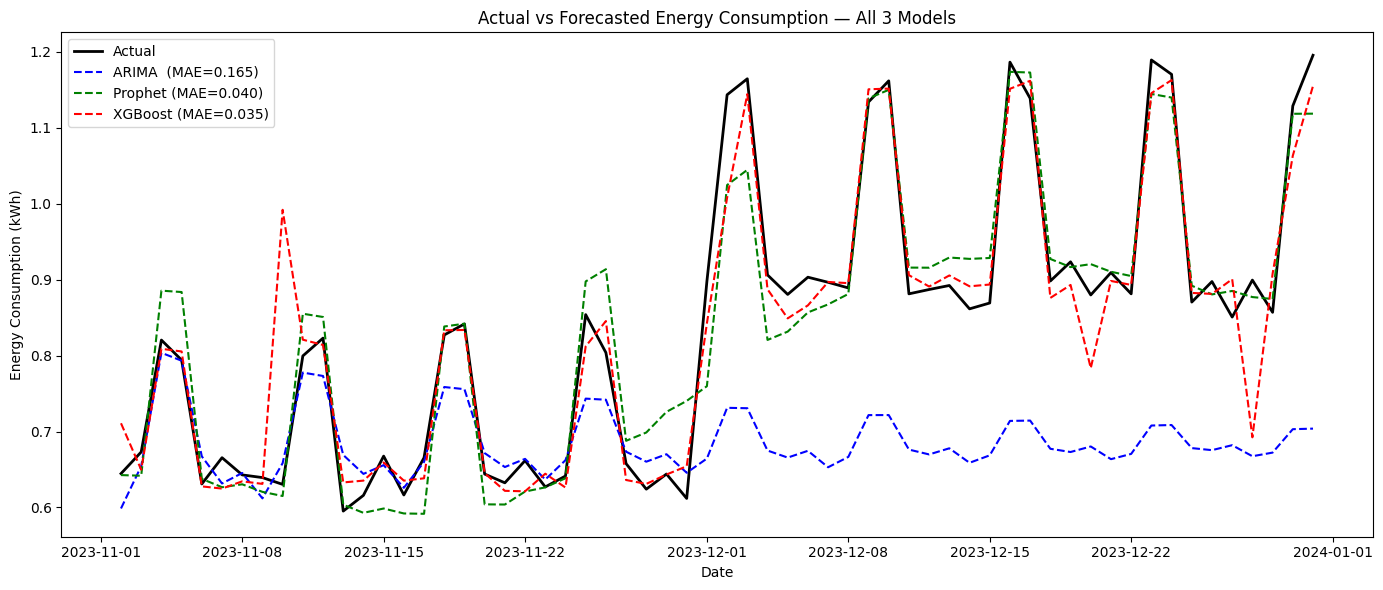

In [19]:
#  COMPARE ALL 3 MODELS

# Test dates for plotting
test_dates = test_daily['ds'].values
actual     = test_daily['y'].values

plt.figure(figsize=(14, 6))

# Actual values
plt.plot(test_dates, actual,
         label='Actual', color='black', linewidth=2)

# ARIMA forecast
plt.plot(test_dates, arima_forecast,
         label=f'ARIMA  (MAE={mae_arima:.3f})',
         color='blue', linestyle='--', linewidth=1.5)

# Prophet forecast
plt.plot(test_dates, prophet_forecast,
         label=f'Prophet (MAE={mae_prophet:.3f})',
         color='green', linestyle='--', linewidth=1.5)

# XGBoost forecast
plt.plot(test_dates, xgb_forecast,
         label=f'XGBoost (MAE={mae_xgb:.3f})',
         color='red', linestyle='--', linewidth=1.5)

plt.title('Actual vs Forecasted Energy Consumption — All 3 Models')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.tight_layout()
plt.show()

MODEL COMPARISON — ENERGY FORECASTING
  Model    MAE   RMSE  MAE Rank  RMSE Rank
  ARIMA 0.1655 0.2248         3          3
Prophet 0.0402 0.0527         2          1
XGBoost 0.0347 0.0640         1          2

Best Model: XGBoost (lowest MAE)


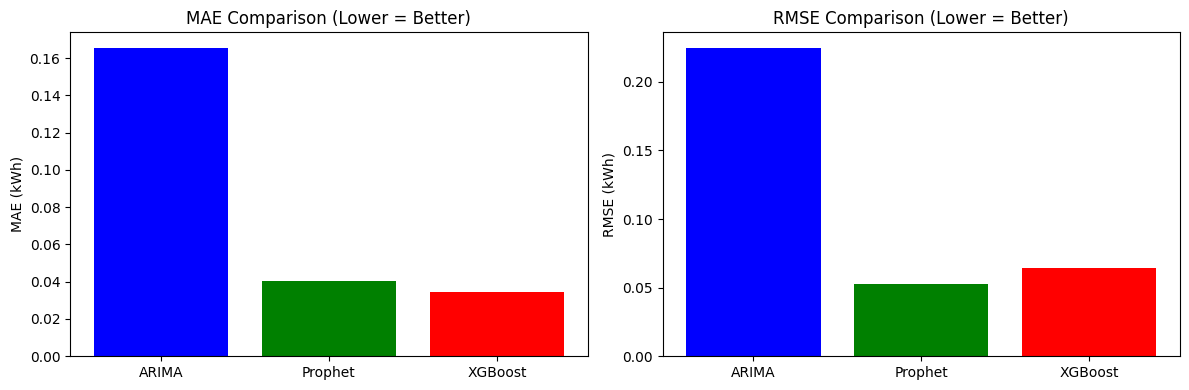

In [20]:
# FINAL COMPARISON TABLE 

results = pd.DataFrame({
    'Model' : ['ARIMA', 'Prophet', 'XGBoost'],
    'MAE'   : [mae_arima,  mae_prophet,  mae_xgb],
    'RMSE'  : [rmse_arima, rmse_prophet, rmse_xgb]
}).round(4)

# Add rank column
results['MAE Rank']  = results['MAE'].rank().astype(int)
results['RMSE Rank'] = results['RMSE'].rank().astype(int)

print("=" * 50)
print("MODEL COMPARISON — ENERGY FORECASTING")
print("=" * 50)
print(results.to_string(index=False))

# Find best model
best_model = results.loc[results['MAE'].idxmin(), 'Model']
print(f"\nBest Model: {best_model} (lowest MAE)")

# Plot comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(results['Model'], results['MAE'],
            color=['blue','green','red'])
axes[0].set_title('MAE Comparison (Lower = Better)')
axes[0].set_ylabel('MAE (kWh)')

axes[1].bar(results['Model'], results['RMSE'],
            color=['blue','green','red'])
axes[1].set_title('RMSE Comparison (Lower = Better)')
axes[1].set_ylabel('RMSE (kWh)')

plt.tight_layout()
plt.show()

